In [1]:
import time
import random
import matplotlib.pyplot as plt

In [3]:
def insertion_sort(arr: list) -> list:
    a = arr[:]  # копия, чтобы не изменять исходный массив

    for i in range(1, len(a)):
        key = a[i]   # элемент, который нужно поставить на правильное место
        j = i - 1    # индекс последнего элемента отсортированной части

        # Сдвигаем элементы отсортированной части вправо,пока не найдём место для key
        while j >= 0 and a[j] > key:
            a[j + 1] = a[j]
            j -= 1

        a[j + 1] = key  # вставляем key на найденную позицию

    return a

def partition_by_lomuto(array: list, low: int, high: int) -> int:
    pivot = array[high]  # Выбираем опорный элемент (последний элемент массива)
    small_boundary = low - 1

    # Проходимся по всему массиву
    for i in range(low, high):
        if array[i] < pivot:  # Если элемент меньше опорного
            small_boundary += 1  # Двигаем границу
            array[small_boundary], array[i] = array[i], array[small_boundary]  # Меняем местами

    final_pivot = small_boundary + 1
    array[final_pivot], array[high] = array[high], array[final_pivot]  # Ставим pivot на своё место

    return final_pivot


def quick_sort(array: list, low: int = 0, high: int = None) -> None:
    high = high if high is not None else len(array) - 1

    if low < high:
        # Случайно выбираем pivot и ставим его в конец, чтобы защититься от худшего случая
        random_pivot_index: int = random.randint(low, high)
        array[random_pivot_index], array[high] = array[high], array[random_pivot_index]

        pivot_pos = partition_by_lomuto(array=array, low=low, high=high)
        quick_sort(array=array, low=low, high=pivot_pos - 1)   # Рекурсивно сортируем левую часть
        quick_sort(array=array, low=pivot_pos + 1, high=high)  # Рекурсивно сортируем правую часть

    return array


def quick_sort_wrapper(arr: list) -> list:
    # Функция для тест: создаёт копию массиваи запускает quick_sort с дефолтными границами
    a = arr[:]
    quick_sort(a)
    return a

In [5]:
def generate_data(size: int, data_type: str) -> list:
    """
    Генерирует массив заданного размера и типа:
      'random'   — случайные числа
      'sorted'   — уже отсортированный по возрастанию
      'reversed' — отсортированный по убыванию
      'nearly'   — почти отсортированный (5% элементов переставлены)
    """
    
    if data_type == 'random':
        return [random.randint(0, 10 * size) for _ in range(size)]

    elif data_type == 'sorted':
        return list(range(size))

    elif data_type == 'reversed':
        return list(range(size, 0, -1))

    elif data_type == 'nearly':
        arr = list(range(size))
        num_swaps = max(1, size // 20)  # переставляем 5% пар элементов
        for _ in range(num_swaps):
            i, j = random.randint(0, size - 1), random.randint(0, size - 1)
            arr[i], arr[j] = arr[j], arr[i]
        return arr

    else:
        raise ValueError(f'Неизвестный тип данных: {data_type}')

In [6]:
def measure_time(sort_func, arr: list, repeats: int = 7) -> float:
    '''
    Запускает sort_func несколько раз (repeats)
    и возвращает среднее время выполнения в секундах.
    '''
    times = []
    for _ in range(repeats):
        data = arr[:]  # копия, чтобы каждый запуск был честным
        start = time.time()
        
        sort_func(data)
        end = time.time()
        times.append(end - start)
        
    return sum(times) / len(times)

In [11]:
SIZES = [1_000, 5_000, 10_000, 50_000]
DATA_TYPES = ['random', 'sorted', 'reversed', 'nearly']
DATA_TYPE_LABELS = {
    'random':   'Случайный',
    'sorted':   'Отсортированный',
    'reversed': 'Обратный',
    'nearly':   'Почти отсортированный',
}
REPEATS = 7

results = {dt: {'Insertion Sort': [], 'Quick Sort': []} for dt in DATA_TYPES}

for data_type in DATA_TYPES:
    print(f'\nТип данных: {DATA_TYPE_LABELS[data_type]}\n')
    for size in SIZES:
        arr = generate_data(size, data_type)

        t_ins = measure_time(insertion_sort,    arr, REPEATS)
        t_qck = measure_time(quick_sort_wrapper, arr, REPEATS)

        results[data_type]['Insertion Sort'].append(t_ins)
        results[data_type]['Quick Sort'].append(t_qck)

        print(f'n={size} : Insertion={t_ins:.4f}s  |  Quick={t_qck:.4f}s')

print('\nТестирование завершено.')


Тип данных: Случайный

n=1000 : Insertion=0.0138s  |  Quick=0.0009s
n=5000 : Insertion=0.3852s  |  Quick=0.0055s
n=10000 : Insertion=1.5447s  |  Quick=0.0116s
n=50000 : Insertion=40.5518s  |  Quick=0.0681s

Тип данных: Отсортированный

n=1000 : Insertion=0.0000s  |  Quick=0.0010s
n=5000 : Insertion=0.0003s  |  Quick=0.0054s
n=10000 : Insertion=0.0007s  |  Quick=0.0114s
n=50000 : Insertion=0.0036s  |  Quick=0.0649s

Тип данных: Обратный

n=1000 : Insertion=0.0253s  |  Quick=0.0009s
n=5000 : Insertion=0.7040s  |  Quick=0.0053s
n=10000 : Insertion=2.8204s  |  Quick=0.0113s
n=50000 : Insertion=77.2915s  |  Quick=0.0744s

Тип данных: Почти отсортированный

n=1000 : Insertion=0.0020s  |  Quick=0.0011s
n=5000 : Insertion=0.0492s  |  Quick=0.0061s
n=10000 : Insertion=0.2194s  |  Quick=0.0128s
n=50000 : Insertion=5.5080s  |  Quick=0.0736s

Тестирование завершено.


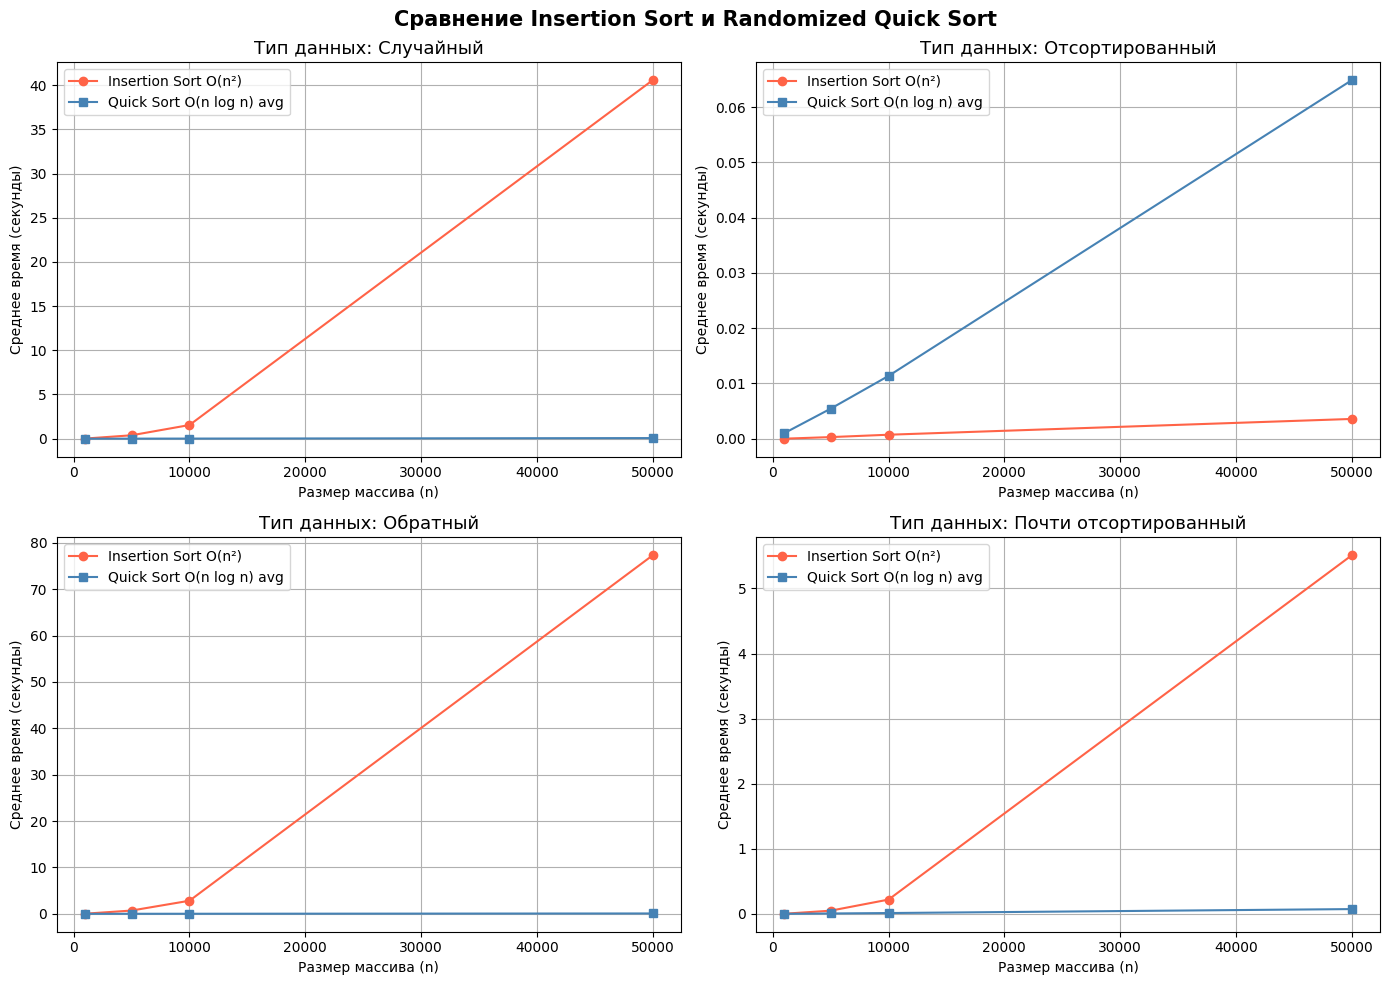

График сохранён как sorting_comparison.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, data_type in enumerate(DATA_TYPES):
    ax = axes[idx]
    ax.plot(SIZES, results[data_type]['Insertion Sort'],
            marker='o', label='Insertion Sort O(n²)', color='tomato')
    ax.plot(SIZES, results[data_type]['Quick Sort'],
            marker='s', label='Quick Sort O(n log n) avg', color='steelblue')

    ax.set_title(f'Тип данных: {DATA_TYPE_LABELS[data_type]}', fontsize=13)
    ax.set_xlabel('Размер массива (n)')
    ax.set_ylabel('Среднее время (секунды)')
    ax.legend()
    ax.grid(True)

plt.suptitle('Сравнение Insertion Sort и Randomized Quick Sort',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sorting_comparison.png', dpi=150)
plt.show()
print('График сохранён как sorting_comparison.png')

In [ ]:
header = f"{'Тип данных':<25} {'n':>7}  {'Insertion Sort':>16}  {'Quick Sort':>12}"
print(header)
print('-' * len(header))

for data_type in DATA_TYPES:
    label = DATA_TYPE_LABELS[data_type]
    for i, size in enumerate(SIZES):
        t_ins = results[data_type]['Insertion Sort'][i]
        t_qck = results[data_type]['Quick Sort'][i]
        faster = '<- IS' if t_ins < t_qck else '<- QS'
        print(f'{label:<25} {size:>7}  {t_ins:>14.4f}s  {t_qck:>10.4f}s  {faster}')
    print()

Тип данных                      n    Insertion Sort    Quick Sort
-----------------------------------------------------------------
Случайный                    1000          0.0138s      0.0009s  <- QS
Случайный                    5000          0.3852s      0.0055s  <- QS
Случайный                   10000          1.5447s      0.0116s  <- QS
Случайный                   50000         40.5518s      0.0681s  <- QS

Отсортированный              1000          0.0000s      0.0010s  <- IS
Отсортированный              5000          0.0003s      0.0054s  <- IS
Отсортированный             10000          0.0007s      0.0114s  <- IS
Отсортированный             50000          0.0036s      0.0649s  <- IS

Обратный                     1000          0.0253s      0.0009s  <- QS
Обратный                     5000          0.7040s      0.0053s  <- QS
Обратный                    10000          2.8204s      0.0113s  <- QS
Обратный                    50000         77.2915s      0.0744s  <- QS

Почти отсорти